In [1]:
# Standard library
import os
import sys
import logging
import datetime
from glob import glob
from typing import Dict, TypedDict, Union

# Third‑party
import yaml
import numpy as np
import xarray as xr

import torch
import torch.utils.data
from torch.utils.data import DistributedSampler, get_worker_info
from torchvision import transforms as tforms

# Local application
from credit.parser import credit_main_parser, training_data_check

In [2]:
from credit.data import LES_Dataset
from credit.transforms import ToTensor_LES, Normalize_LES

In [3]:
from credit.forecast import load_forecasts

In [4]:
# from credit.data import encode_datetime64

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
import time

In [7]:
from credit.data import (
    generate_datetime,
    hour_to_nanoseconds,
    nanoseconds_to_year,
    extract_month_day_hour,
    find_common_indices,
    concat_and_reshape,
    reshape_only,
    get_forward_data,
    drop_var_from_dataset,
    find_key_for_number,
    filter_ds,
    ensure_numpy_datetime,
)

In [8]:
# Logging setup
logger = logging.getLogger(__name__)

# single node steup
rank = 0
world_size = 1

In [9]:
config_name = '/glade/work/ksha/DWC_runs/FE_base/model_predict.yml'
# Read YAML file
with open(config_name, 'r') as stream:
    conf = yaml.safe_load(stream)

In [10]:
conf = credit_main_parser(conf, parse_training=False, parse_predict=True, print_summary=True)

Upper-air variables: ['u', 'v', 'w', 'theta', 'rho', 'qv']
Surface variables: []
Dynamic forcing variables: []
Diagnostic variables: ['TKE_0']
Forcing variables: []
Static variables: ['BuildingHeights_norm', 'BuildingMask_norm', 'LandCover_norm', 'topoPos_norm', 'topoWRF_norm']


In [11]:
ds_domain = get_forward_data(conf["loss"]["latitude_weights"])

## dataset dev

In [12]:
Array = Union[np.ndarray, xr.DataArray]

class Sample(TypedDict):
    # Shape: batch_size, seq_length, lat, lon, lev
    WRF_input: Array
    WRF_target: Array
    boundary_input: Array
    time_encode: Array
    datetime_index: Array

In [13]:
# pick a year
test_years_range = [9, 13]

param_interior = {}
# --------------- #
# upper air files
upper_files = sorted(glob(conf["data"]["save_loc"]))

# --------------- #
# surface files
if ('surface_variables' in conf['data']) and (len(conf['data']['surface_variables']) > 0):
    list_surf_ds = sorted(glob(conf["data"]["save_loc_surface"]))
else:
    list_surf_ds = None

# --------------- #
# dyn forcing files
if ('dynamic_forcing_variables' in conf['data']) and (len(conf['data']['dynamic_forcing_variables']) > 0):
    list_dyn_forcing_ds = sorted(glob(conf["data"]["save_loc_dynamic_forcing"]))
else:
    list_dyn_forcing_ds = None

# --------------- #
# diagnostic files
if ('diagnostic_variables' in conf['data']) and (len(conf['data']['diagnostic_variables']) > 0):
    list_diag_ds = sorted(glob(conf["data"]["save_loc_diagnostic"]))
else:
    list_diag_ds = None

# convert year info to str for file name search
test_years = [f"{year:02d}" for year in range(test_years_range[0], test_years_range[1])]

# Filter files
test_files = [file for file in upper_files if any(year in file for year in test_years)]

if list_surf_ds is not None:
    test_list_surf_ds = [file for file in list_surf_ds if any(year in file for year in test_years)]
else:
    test_list_surf_ds = None
    
if list_dyn_forcing_ds is not None:
    test_list_dyn_forcing_ds = [file for file in list_dyn_forcing_ds if any(year in file for year in test_years)]
else:
    test_list_dyn_forcing_ds = None

if list_diag_ds is not None:
    test_list_diag_ds = [file for file in list_diag_ds if any(year in file for year in test_years)]
else:
    test_list_diag_ds = None
    
param_interior['varname_upper_air'] = conf['data']['variables']
param_interior['varname_surface'] = conf['data']['surface_variables']
param_interior['varname_dyn_forcing'] = conf['data']['dynamic_forcing_variables']
param_interior['varname_forcing'] = conf['data']['forcing_variables']
param_interior['varname_static'] = conf['data']['static_variables']
param_interior['varname_diagnostic'] = conf['data']['diagnostic_variables']
param_interior['filename_forcing'] = conf['data']['save_loc_forcing']
param_interior['filename_static'] = conf['data']['save_loc_static']
# --------------------------------------------------- #

param_interior['filenames'] = test_files
param_interior['filename_surface'] = test_list_surf_ds
param_interior['filename_dyn_forcing'] = test_list_dyn_forcing_ds
param_interior['filename_diagnostic'] = test_list_diag_ds
param_interior['history_len'] = conf["data"]["history_len"]
param_interior['forecast_len'] = conf["data"]["forecast_len"]

In [14]:
test_years

['09', '10', '11', '12']

In [15]:
def subset_patch(
    ds: xr.Dataset,
    input_size,
    start,   # (ilat0, ilon0). If None → center crop
    lat_name = "yIndex",
    lon_name = "xIndex",
) -> xr.Dataset:
    """
    Return a spatial subset of shape (time, input_size[0], input_size[1]).
    Assumes ds has dims (time, lat, lon).
    """
    H = ds.dims[lat_name]
    W = ds.dims[lon_name]
    h, w = input_size

    if h > H or w > W:
        raise ValueError(f"Requested patch {h}x{w} exceeds dataset size {H}x{W}")

    if start is None:
        i0 = (H - h) // 2
        j0 = (W - w) // 2
    else:
        i0, j0 = start
        if i0 < 0 or j0 < 0 or i0 + h > H or j0 + w > W:
            raise ValueError(f"Start {(i0, j0)} with size {(h, w)} is out of bounds for {H}x{W}")

    i1 = i0 + h
    j1 = j0 + w
    
    print((i0, i1))
    print((j0, j1))
    
    return ds.isel({lat_name: slice(i0, i1), lon_name: slice(j0, j1)})

In [50]:
class LES_Predict(torch.utils.data.IterableDataset):
    def __init__(
        self,
        param_interior,
        data_lookup,
        rank,
        world_size,
        transform=None,
    ):
        ## no diagnostics because they are output only
        # varname_diagnostic = None
        # ========================================================== #
        # LES domain variable and filename info
        varname_upper_air = param_interior['varname_upper_air']
        varname_surface = param_interior['varname_surface']
        varname_dyn_forcing = param_interior['varname_dyn_forcing']
        varname_forcing = param_interior['varname_forcing']
        varname_static = param_interior['varname_static']
        varname_diagnostic = param_interior['varname_diagnostic']
        filenames = param_interior['filenames']
        filename_surface = param_interior['filename_surface']
        filename_dyn_forcing = param_interior['filename_dyn_forcing']
        filename_forcing = param_interior['filename_forcing']
        filename_static = param_interior['filename_static']
        filename_diagnostic = param_interior['filename_diagnostic']
        
        # ----------------------------------------------------------- #
        # collecting xr.datasets
        list_upper_ds = []
        list_surf_ds = []
        list_dyn_forcing_ds = []
        list_diag_ds = []
        filenames = sorted(filenames)
        all_ds = [get_forward_data(fn) for fn in filenames]
        
        # 1. Upper‐air
        list_upper_ds = [filter_ds(ds, varname_upper_air) for ds in all_ds]
        
        # 2. Surface
        if filename_surface:
            list_surf_ds = [filter_ds(ds, varname_surface) for ds in all_ds]
        else:
            list_surf_ds = False

        # 3. Dynamic forcing
        if filename_dyn_forcing:
            list_dyn_forcing_ds = [filter_ds(ds, varname_dyn_forcing) for ds in all_ds]
        else:
            list_dyn_forcing_ds = False
            
        # 4. Diagnostics
        if filename_diagnostic:
            list_diag_ds = [filter_ds(ds, varname_diagnostic) for ds in all_ds]
        else:
            list_diag_ds = False
            
        self.list_upper_ds = list_upper_ds
        self.list_surf_ds = list_surf_ds
        self.list_dyn_forcing_ds = list_dyn_forcing_ds
        self.list_diag_ds = list_diag_ds

        # -------------------------------------- #
        # file names
        self.filenames = filenames  # <------------------------ a list of files
        self.filename_surface = filename_surface  # <---------- a list of files
        self.filename_dyn_forcing = filename_dyn_forcing  # <-- a list of files
        self.filename_forcing = filename_forcing  # <-- single file
        self.filename_static = filename_static  # <---- single file
        self.filename_diagnostic = filename_diagnostic  # <---- single file
        
        # -------------------------------------------------------------------------- #
        # forcing file
        self.filename_forcing = filename_forcing
        if self.filename_forcing is not None:
            # drop variables if they are not in the config
            ds = get_forward_data(filename_forcing)
            ds_forcing = drop_var_from_dataset(ds, varname_forcing).load()
            self.xarray_forcing = ds_forcing
        else:
            self.xarray_forcing = False

        # -------------------------------------------------------------------------- #
        # static file
        self.filename_static = filename_static
        if self.filename_static is not None:
            # drop variables if they are not in the config
            ds = get_forward_data(filename_static)
            ds_static = drop_var_from_dataset(ds, varname_static).load()
            self.xarray_static = ds_static
        else:
            self.xarray_static = False
            
        # -------------------------------------- #
        # other settings
        self.rank = rank
        self.world_size = world_size
        self.transform = transform
        self.history_len = param_interior['history_len']
        self.data_lookup = data_lookup
        #self.lead_time_periods = lead_time_periods
    
    def load_zarr_as_input(self, i_file, i_init_start, i_init_end, mode="input"):
        
        # sliced_x: the final output, starts with an upper air xr.dataset
        sliced_x = self.list_upper_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
        
        # surface variables
        if self.filename_surface is not None:
            sliced_surface = self.list_surf_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
            #sliced_surface["time"] = sliced_x["time"]
            sliced_x = sliced_x.merge(sliced_surface)

        if mode == "input":
            # dynamic forcing variables
            if self.filename_dyn_forcing is not None:
                sliced_dyn_forcing = self.list_dyn_forcing_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
                #sliced_dyn_forcing["time"] = sliced_x["time"]
                sliced_x = sliced_x.merge(sliced_dyn_forcing)
                
            if self.filename_forcing is not None:
                sliced_forcing = self.xarray_forcing.copy() # <-- shallow copy
                month_day_forcing = extract_month_day_hour(np.array(sliced_forcing["time"]))
                month_day_inputs = extract_month_day_hour(np.array(sliced_x["time"]))
                # indices to subset
                ind_forcing, _ = find_common_indices(month_day_forcing, month_day_inputs)
                sliced_forcing = sliced_forcing.isel(time=ind_forcing)
                sliced_forcing["time"] = sliced_x["time"]
                sliced_x = sliced_x.merge(sliced_forcing)
                
            if self.filename_static is not None:
                sliced_static = self.xarray_static.copy() # <-- shallow copy
                sliced_static = sliced_static.expand_dims(dim={"time": len(sliced_x["time"])})
                sliced_static["time"] = sliced_x["time"]
                # merge static to sliced_x
                sliced_x = sliced_x.merge(sliced_static)

        elif mode == "target":
            # diagnostic
            if self.filename_diagnostic is not None:
                sliced_diagnostic = self.list_diag_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
                # sliced_diagnostic["time"] = sliced_x["time"]
                sliced_x = sliced_x.merge(sliced_diagnostic)
                
        return sliced_x
        
    def __len__(self):
        return len(self.data_lookup)

    def __iter__(self):
        worker_info = get_worker_info()
        num_workers = worker_info.num_workers if worker_info is not None else 1
        worker_id = worker_info.id if worker_info is not None else 0
        
        sampler = DistributedSampler(
            self,
            num_replicas=num_workers * self.world_size,
            rank=self.rank * num_workers + worker_id,
            shuffle=False,
        )
        
        for index in sampler:
            # get the init time info for the current sample
            data_lookup = self.data_lookup

            i_file, i_init_start, i_init_end, N_times = data_lookup[index]
            
            while i_init_end <= N_times:
            # for k, _ in enumerate(data_lookup):
                # the first initialization time: get initalization from data
                # i_file, i_init_start, i_init_end, N_times = data_lookup

                # allocate output dict
                output_dict = {}

                # get all inputs in one xr.Dataset
                sliced_x = self.load_zarr_as_input(i_file, i_init_start, i_init_end, mode="input")
                sliced_y = self.load_zarr_as_input(i_file, i_init_end + 1, i_init_end + 1, mode="target")

                sliced_x = subset_patch(sliced_x, input_size=(256, 256), start=None)
                sliced_y = subset_patch(sliced_y, input_size=(256, 256), start=None)

                print((i_init_start, i_init_end))
                
                i_init_start += 1
                i_init_end += 1
                
                sample_x = {
                    "LES_input": sliced_x,
                    "LES_target": sliced_y,
                }

                if self.transform:
                    sample_x = self.transform(sample_x)

                for key in sample_x.keys():
                    output_dict[key] = sample_x[key]

                # <--- !! 'forecast_hour' is actually "forecast_step" but named by assuming hourly
                output_dict["forecast_hour"] = i_init_end
                
                # Adjust stopping condition
                output_dict["stop_forecast"] = (i_init_end == N_times)
                output_dict["datetime"] = sliced_x.time.values.astype("datetime64[s]").astype(int)[-1]

                # return output_dict
                yield output_dict
                
                if output_dict["stop_forecast"]:
                    break

In [51]:
to_tensor_scaler = ToTensor_LES(conf)
normalizer = Normalize_LES(conf)
transforms = tforms.Compose([normalizer, to_tensor_scaler])

In [70]:
# fcst_datetime = load_forecasts(conf)

dataset = LES_Predict(
    param_interior,
     [[0, 0, 0, 89]],
    transform=None,
    rank=0,
    world_size=1
)

In [1]:
# for batch_single in iter(dataset):
#     print(batch_single["stop_forecast"])

In [72]:
batch_single['LES_input']

<xarray.Dataset>
Dimensions:               (time: 1, zIndex: 17, yIndex: 256, xIndex: 256)
Coordinates:
  * time                  (time) datetime64[ns] 2018-01-24T12:59:00
  * xIndex                (xIndex) int32 320 321 322 323 324 ... 572 573 574 575
  * yIndex                (yIndex) int32 319 320 321 322 323 ... 571 572 573 574
  * zIndex                (zIndex) int32 0 4 8 12 16 20 24 ... 44 48 52 56 60 64
Data variables:
    u                     (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    v                     (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    w                     (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    theta                 (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    rho                   (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    qv                    (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    BuildingHeights_norm  (time, yIndex, xIndex) float32 0.2353 0.2353 ... 0.0
    BuildingMask_norm     (time, yIndex, xIndex) float32 1.0 1.0 1.0 ... 0.0 0.0
    LandCover_norm        (time, yIndex, xIndex) float32 0.2526 ... 0.2526
    topoPos_norm          (time, yIndex, xIndex) float32 0.06733 ... 0.4744
    topoWRF_norm          (time, yIndex, xIndex) float32 -0.9389 ... 0.9602
Attributes:
    NCO:                        netCDF Operators version 5.2.4 (Homepage = ht...
    history:                    Thu Feb  6 14:10:16 2025: ncap2 -A -s BH_Topo...
    history_of_appended_files:  Thu May 16 17:07:03 2024: Appended file /glad...

In [73]:
batch_single['LES_target']

<xarray.Dataset>
Dimensions:  (time: 1, zIndex: 17, yIndex: 256, xIndex: 256)
Coordinates:
  * time     (time) datetime64[ns] 2018-01-24T12:59:30
  * xIndex   (xIndex) int32 320 321 322 323 324 325 ... 570 571 572 573 574 575
  * yIndex   (yIndex) int32 319 320 321 322 323 324 ... 569 570 571 572 573 574
  * zIndex   (zIndex) int32 0 4 8 12 16 20 24 28 32 36 40 44 48 52 56 60 64
Data variables:
    u        (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    v        (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    w        (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    theta    (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    rho      (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    qv       (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
    TKE_0    (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 17, 256, 256), meta=np.ndarray>
Attributes:
    NCO:                        netCDF Operators version 5.2.4 (Homepage = ht...
    history:                    Thu Feb  6 14:10:16 2025: ncap2 -A -s BH_Topo...
    history_of_appended_files:  Thu May 16 17:07:03 2024: Appended file /glad...

In [21]:
batch = {}
keys = list(batch_single.keys())
keys = keys[:-3]

for var in keys:
    batch[var] = batch_single[var].unsqueeze(0) # give a single sample batch dimension

In [22]:
# date_time = batch["datetime"].item()
# forecast_hour = batch["forecast_hour"].item()

if "x_surf" in batch:
    # combine x and x_surf
    # input: (batch_num, time, var, level, lat, lon), (batch_num, time, var, lat, lon)
    # output: (batch_num, var, time, lat, lon), 'x' first and then 'x_surf'
    x = concat_and_reshape(batch["x"], batch["x_surf"])
else:
    # no x_surf
    x = reshape_only(batch["x"])

# init_datetime = datetime.utcfromtimestamp(date_time)
# init_datetime_str = init_datetime.strftime("%Y-%m-%dT%HZ")

# -------------------------------------------------------------------------------------- #
# add forcing and static variables (regardless of fcst hours)
if "x_forcing_static" in batch:
    # (batch_num, time, var, lat, lon) --> (batch_num, var, time, lat, lon)
    x_forcing_batch = batch["x_forcing_static"].permute(0, 2, 1, 3, 4)
    
    # concat on var dimension
    x = torch.cat((x, x_forcing_batch), dim=1)

# -------------------------------------------------------------------------------------- #
# Load y-truth
if "y_surf" in batch:
    # combine y and y_surf
    y = concat_and_reshape(batch["y"], batch["y_surf"])
else:
    # no y_surf
    y = reshape_only(batch["y"])
    
# adding diagnostic vars to y
if "y_diag" in batch:
    y_diag_batch = reshape_only(batch["y_diag"])
    
    y = torch.cat((y, y_diag_batch), dim=1)

In [23]:
y.shape

torch.Size([1, 119, 1, 256, 256])

In [24]:
batch["y_diag"].shape

torch.Size([1, 1, 1, 17, 256, 256])

In [46]:
batch_single['x_time_encode'].shape

torch.Size([16])

In [ ]:
# t0 = batch_single['WRF_input']['time'].values
# t1 = batch_single['WRF_target']['time'].values
# t2 = batch_single['boundary_input']['time'].values
# time_encode = encode_datetime64(np.concatenate([t0, t1, t2]))

In [47]:
t0 = np.array(['2020-01-01T00:00:00.000000000'], dtype='datetime64[ns]')
t1 = np.array(['2020-01-01T00:00:00.000000000'], dtype='datetime64[ns]')
t2 = np.array(['2020-01-01T00:00:00.000000000', '2020-01-01T06:00:00.000000000'], dtype='datetime64[ns]')
time_encode_np = encode_datetime64(np.concatenate([t0, t1, t2]))
torch.as_tensor(time_encode_np).type(torch.float32).shape

torch.Size([16])

In [ ]:
# t0 = np.array(['2019-12-31T23:00:00.000000000'], dtype='datetime64[ns]')
# t1 = np.array(['2020-01-01T00:00:00.000000000'], dtype='datetime64[ns]')
# t2 = np.array(['2020-01-01T00:00:00.000000000', '2020-01-01T06:00:00.000000000'], dtype='datetime64[ns]')
# time_encode_np = encode_datetime64(np.concatenate([t0, t1, t2]))
# torch.as_tensor(time_encode_np).type(torch.float32)

In [31]:
t2

array(['2020-01-01T00:00:00.000000000', '2020-01-01T06:00:00.000000000'],
      dtype='datetime64[ns]')

In [ ]:
t0 = sliced_x['time'].values
time_encode = encode_datetime64(t0)

In [25]:
print(batch_single['x'].shape)
print(batch_single['x_boundary'].shape)
print(batch_single['x_surf_boundary'].shape)

torch.Size([1, 5, 12, 336, 336])
torch.Size([2, 4, 11, 88, 112])
torch.Size([2, 4, 88, 112])


In [26]:
print((batch_single['x'].min(), batch_single['x'].max()))
print((batch_single['y'].min(), batch_single['y'].max()))
print((batch_single['x_boundary'].min(), batch_single['x_boundary'].max()))
print((batch_single['x_surf_boundary'].min(), batch_single['x_surf_boundary'].max()))

(tensor(-37.2928), tensor(9.4572))
(tensor(-37.2915), tensor(9.4439))
(tensor(-4.8164), tensor(4.7816))
(tensor(-51.9736), tensor(14.2522))


In [20]:
# batch['boundary_input']

In [21]:
# batch['WRF_input']

In [49]:
#import copy

In [13]:
class WRF_Predict(torch.utils.data.IterableDataset):
    def __init__(
        self,
        param_interior,
        param_outside,
        fcst_datetime,
        lead_time_periods,
        rank,
        world_size,
        transform=None,
    ):
        ## no diagnostics because they are output only
        # varname_diagnostic = None
        # ========================================================== #
        # WRF domain variable and filename info
        varname_upper_air = param_interior['varname_upper_air']
        varname_surface = param_interior['varname_surface']
        varname_dyn_forcing = param_interior['varname_dyn_forcing']
        varname_forcing = param_interior['varname_forcing']
        varname_static = param_interior['varname_static']
        varname_diagnostic = param_interior['varname_diagnostic']
        filenames = param_interior['filenames']
        filename_surface = param_interior['filename_surface']
        filename_dyn_forcing = param_interior['filename_dyn_forcing']
        filename_forcing = param_interior['filename_forcing']
        filename_static = param_interior['filename_static']
        filename_diagnostic = param_interior['filename_diagnostic']
        
        # ----------------------------------------------------------- #
        # collecting xr.datasets
        list_upper_ds = []
        list_surf_ds = []
        list_dyn_forcing_ds = []
        list_diag_ds = []
        filenames = sorted(filenames)
        all_ds = [get_forward_data(fn) for fn in filenames]
        
        # 1. Upper‐air
        list_upper_ds = [filter_ds(ds, varname_upper_air) for ds in all_ds]
        
        # 2. Surface
        if filename_surface:
            list_surf_ds = [filter_ds(ds, varname_surface) for ds in all_ds]
        else:
            list_surf_ds = False

        # 3. Dynamic forcing
        if filename_dyn_forcing:
            list_dyn_forcing_ds = [filter_ds(ds, varname_dyn_forcing) for ds in all_ds]
        else:
            list_dyn_forcing_ds = False
            
        # 4. Diagnostics
        if filename_diagnostic:
            list_diag_ds = [filter_ds(ds, varname_diagnostic) for ds in all_ds]
        else:
            list_diag_ds = False
            
        self.list_upper_ds = list_upper_ds
        self.list_surf_ds = list_surf_ds
        self.list_dyn_forcing_ds = list_dyn_forcing_ds
        self.list_diag_ds = list_diag_ds

        # -------------------------------------- #
        # file names
        self.filenames = filenames  # <------------------------ a list of files
        self.filename_surface = filename_surface  # <---------- a list of files
        self.filename_dyn_forcing = filename_dyn_forcing  # <-- a list of files
        self.filename_forcing = filename_forcing  # <-- single file
        self.filename_static = filename_static  # <---- single file
        self.filename_diagnostic = filename_diagnostic  # <---- single file

        # # -------------------------------------- #
        # # var names
        # self.varname_upper_air = varname_upper_air
        # self.varname_surface = varname_surface
        # self.varname_dyn_forcing = varname_dyn_forcing
        # self.varname_forcing = varname_forcing
        # self.varname_static = varname_static
        # self.varname_diagnostic = varname_diagnostic
        
        # -------------------------------------------------------------------------- #
        # forcing file
        self.filename_forcing = filename_forcing
        if self.filename_forcing is not None:
            # drop variables if they are not in the config
            ds = get_forward_data(filename_forcing)
            ds_forcing = drop_var_from_dataset(ds, varname_forcing).load()
            self.xarray_forcing = ds_forcing
        else:
            self.xarray_forcing = False

        # -------------------------------------------------------------------------- #
        # static file
        self.filename_static = filename_static
        if self.filename_static is not None:
            # drop variables if they are not in the config
            ds = get_forward_data(filename_static)
            ds_static = drop_var_from_dataset(ds, varname_static).load()
            self.xarray_static = ds_static
        else:
            self.xarray_static = False

        # ========================================================== #
        # boundary variable and filename info
        varname_upper_air_outside = param_outside['varname_upper_air']
        varname_surface_outside = param_outside['varname_surface']
        filenames_outside = param_outside['filenames']
        filename_surface_outside = param_outside['filename_surface']
        # ----------------------------------------------------------- #
        # collecting xr.datasets
        list_upper_ds_outside = []
        list_surf_ds_outside = []
        filenames_outside = sorted(filenames_outside)
        
        for fn_outside in filenames_outside:
            # drop variables if they are not in the config
            ds_outside = get_forward_data(filename=fn_outside)
            ds_upper_outside = drop_var_from_dataset(ds_outside, varname_upper_air_outside)

            if filename_surface_outside is not None:
                ds_surf_outside = drop_var_from_dataset(ds_outside, varname_surface_outside)
                list_surf_ds_outside.append(ds_surf_outside)
            else:
                self.list_surf_ds_outside = False

            list_upper_ds_outside.append(ds_upper_outside)

        self.list_upper_ds_outside = list_upper_ds_outside
        self.list_surf_ds_outside = list_surf_ds_outside
        self.history_len_outside = param_outside['history_len']
        self.forecast_len_outside = param_outside['forecast_len']
        # -------------------------------------------------------------------------- #
        # get sample indices from boundary upper-air files:
        self.outside_file_year_range = [
            int(np.datetime_as_string(self.list_upper_ds_outside[0]["time"][0].values, unit="Y")),
            int(np.datetime_as_string(self.list_upper_ds_outside[-1]["time"][0].values, unit="Y"))
        ]
        
        self.outside_file_indices = {}  # <------ change
        for ind_file, outside_file_xarray in enumerate(self.list_upper_ds_outside):
            self.outside_file_indices[str(ind_file)] = outside_file_xarray["time"].values
        
        # -------------------------------------- #
        # other settings
        self.rank = rank
        self.world_size = world_size
        self.transform = transform
        self.history_len = param_interior['history_len']
        self.init_datetime = fcst_datetime
        self.lead_time_periods = lead_time_periods
    
    def load_zarr_as_input(self, i_file, i_init_start, i_init_end, mode="input"):
        
        # sliced_x: the final output, starts with an upper air xr.dataset
        sliced_x = self.list_upper_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
        
        # surface variables
        if self.filename_surface is not None:
            sliced_surface = self.list_surf_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
            #sliced_surface["time"] = sliced_x["time"]
            sliced_x = sliced_x.merge(sliced_surface)

        if mode == "input":
            # dynamic forcing variables
            if self.filename_dyn_forcing is not None:
                sliced_dyn_forcing = self.list_dyn_forcing_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
                #sliced_dyn_forcing["time"] = sliced_x["time"]
                sliced_x = sliced_x.merge(sliced_dyn_forcing)


            if self.filename_forcing is not None:
                sliced_forcing = self.xarray_forcing.copy() # <-- shallow copy
                month_day_forcing = extract_month_day_hour(np.array(sliced_forcing["time"]))
                month_day_inputs = extract_month_day_hour(np.array(sliced_x["time"]))
                # indices to subset
                ind_forcing, _ = find_common_indices(month_day_forcing, month_day_inputs)
                sliced_forcing = sliced_forcing.isel(time=ind_forcing)
                sliced_forcing["time"] = sliced_x["time"]
                sliced_x = sliced_x.merge(sliced_forcing)
                
            if self.filename_static is not None:
                sliced_static = self.xarray_static.copy() # <-- shallow copy
                sliced_static = sliced_static.expand_dims(dim={"time": len(sliced_x["time"])})
                sliced_static["time"] = sliced_x["time"]
                # merge static to sliced_x
                sliced_x = sliced_x.merge(sliced_static)

        elif mode == "target":
            # diagnostic
            if self.filename_diagnostic is not None:
                sliced_diagnostic = self.list_diag_ds[i_file].isel(time=slice(i_init_start, i_init_end + 1))
                # sliced_diagnostic["time"] = sliced_x["time"]
                sliced_x = sliced_x.merge(sliced_diagnostic)
                
        return sliced_x

    def find_start_stop_indices(self, index):
        # ============================================================================ #
        # shift hours for history_len > 1, becuase more than one init times are needed
        shifted_hours = self.lead_time_periods * (self.history_len - 1)
        # ============================================================================ #
        # subtrack shifted_hour form the 1st & last init times
        # convert to datetime object

        #init_datetime = copy.deepcopy(self.init_datetime)
        init_datetime = self.init_datetime
        
        init_datetime[index][0] = datetime.datetime.strptime(
            init_datetime[index][0], "%Y-%m-%d %H:%M:%S") - datetime.timedelta(hours=shifted_hours)
        init_datetime[index][1] = datetime.datetime.strptime(
            init_datetime[index][1], "%Y-%m-%d %H:%M:%S") - datetime.timedelta(hours=shifted_hours)

        # convert the 1st & last init times to a list of init times
        init_datetime[index] = generate_datetime(
            init_datetime[index][0],
            init_datetime[index][1],
            self.lead_time_periods,
        )
        
        # convert datetime obj to nanosecondes
        init_time_list_dt = [
            np.datetime64(date.strftime("%Y-%m-%d %H:%M:%S"))
            for date in init_datetime[index]
        ]

        # init_time_list_np: a list of python datetime objects, each is a forecast step
        # init_time_list_np[0]: the first initialization time
        # init_time_list_np[t]: the forcasted time of the (t-1)th step; the initialization time of the t-th step
        self.init_time_list_np = [
            np.datetime64(str(dt_obj) + ".000000000").astype(datetime.datetime)
            for dt_obj in init_time_list_dt
        ]

        info = []
        for init_time in self.init_time_list_np:
            for i_file, ds in enumerate(self.list_upper_ds):
                # get the year of the current file
                
                ds_values = ds["time"].values
                
                time_value = ensure_numpy_datetime(ds_values[0])
                ds_year = int(np.datetime_as_string(time_value, unit="Y"))
                
                # get the first and last years of init times
                init_year0 = nanoseconds_to_year(init_time)

                # found the right yearly file
                if init_year0 == ds_year:
                    N_times = len(ds_values)

                    # convert ds['time'] to a list of nanoseconds
                    ds_time_list = [
                        np.datetime64(ensure_numpy_datetime(ds_time)).astype('datetime64[ns]').astype(int)
                        for ds_time in ds_values
                    ]

                    ds_start_time = ds_time_list[0]
                    ds_end_time = ds_time_list[-1]

                    init_time_start = init_time
                    # if initalization time is within this (yearly) xr.Dataset
                    #print('Check time values, data.py: start time',ds_start_time)
                    #print('Check time values, data.py: end time' ,ds_end_time)
                    #print('Check time values, data.py: init time' , init_time_start)
                    
                    if ds_start_time <= init_time_start <= ds_end_time:
                        # try getting the index of the first initalization time
                        i_init_start = ds_time_list.index(init_time_start)

                        # for multiple init time inputs (history_len > 1), init_end is different for init_start
                        init_time_end = init_time_start + hour_to_nanoseconds(shifted_hours)

                        # see if init_time_end is alos in this file
                        if ds_start_time <= init_time_end <= ds_end_time:
                            # try getting the index
                            i_init_end = ds_time_list.index(init_time_end)
                        else:
                            # this set of initalizations have crossed years
                            # get the last element of the current file
                            # we have anthoer section that checks additional input data
                            i_init_end = len(ds_time_list) - 1

                        info.append([i_file, i_init_start, i_init_end, N_times])
                        
        return info

    def __len__(self):
        return len(self.init_datetime)

    def __iter__(self):
        worker_info = get_worker_info()
        num_workers = worker_info.num_workers if worker_info is not None else 1
        worker_id = worker_info.id if worker_info is not None else 0
        
        sampler = DistributedSampler(
            self,
            num_replicas=num_workers * self.world_size,
            rank=self.rank * num_workers + worker_id,
            shuffle=False,
        )
        
        for index in sampler:
            # get the init time info for the current sample
            data_lookup = self.find_start_stop_indices(index)

            for k, _ in enumerate(self.init_time_list_np):
                # the first initialization time: get initalization from data
                i_file, i_init_start, i_init_end, N_times = data_lookup[k]

                # allocate output dict
                output_dict = {}

                # get all inputs in one xr.Dataset
                sliced_x = self.load_zarr_as_input(i_file, i_init_start, i_init_end, mode="input")

                # Check if additional data from the next file is needed
                if (len(sliced_x["time"]) < self.history_len) or (i_init_end + 1 >= N_times):
                    
                    # Load excess data from the next file
                    next_file_idx = self.filenames.index(self.filenames[i_file]) + 1

                    if next_file_idx >= len(self.filenames):
                        # not enough input data to support this forecast
                        raise OSError("You have reached the end of the available data. Exiting.")

                    else:
                        sliced_y = self.load_zarr_as_input(i_file, i_init_end, i_init_end, mode="target")

                        # i_init_start = 0 because we need the beginning of the next file only
                        sliced_x_next = self.load_zarr_as_input(next_file_idx, 0, self.history_len, mode="input")
                        sliced_y_next = self.load_zarr_as_input(next_file_idx, 0, 1, mode="target")
                        # 1 becuase taregt is one step a time

                        # Concatenate excess data from the next file with the current data
                        sliced_x_combine = xr.concat([sliced_x, sliced_x_next], dim="time")
                        sliced_y_combine = xr.concat([sliced_y, sliced_y_next], dim="time")

                        sliced_x = sliced_x_combine.isel(time=slice(0, self.history_len))
                        sliced_y = sliced_y_combine.isel(time=slice(self.history_len, self.history_len + 1))
                else:
                    sliced_y = self.load_zarr_as_input(i_file, i_init_end + 1, i_init_end + 1, mode="target")


                # ========================== #
                # boundary conditions
                # sliced_y['time']
                time_boundary = sliced_y['time'].values[0] # <--- assuming single time value here
                time_round = next_six_hour(time_boundary)
                
                if self.history_len_outside == 1:    
                    time_year = int(np.datetime_as_string(time_round, unit="Y"))
                    ind_year = time_year - self.outside_file_year_range[0]
                    ind_date = np.searchsorted(self.outside_file_indices[str(ind_year)], time_round)
                    ds_upper_outside = self.list_upper_ds_outside[ind_year].isel(time=slice(ind_date, ind_date+1))
                    ds_surf_outside = self.list_surf_ds_outside[ind_year].isel(time=slice(ind_date, ind_date+1))
                    ds_outside = xr.merge([ds_upper_outside, ds_surf_outside])
        
                else:
                    list_ds_upper_outside_slice = []
                    list_ds_surf_outside_slice = []
                    
                    for i_time_backward in range(self.history_len_outside):
                        time_round_loop = previous_six_hour_steps(time_round, i_time_backward)
                        time_year = int(np.datetime_as_string(time_round_loop, unit="Y"))
                        ind_year = time_year - self.outside_file_year_range[0]
                        ind_date = np.searchsorted(self.outside_file_indices[str(ind_year)], time_round_loop)
                        list_ds_upper_outside_slice.append(self.list_upper_ds_outside[ind_year].isel(time=slice(ind_date, ind_date+1)))
                        list_ds_surf_outside_slice.append(self.list_surf_ds_outside[ind_year].isel(time=slice(ind_date, ind_date+1)))
                        
                    ds_upper_outside = xr.concat(list_ds_upper_outside_slice[::-1], dim='time') # ::-1 so the latest time is the last
                    ds_surf_outside = xr.concat(list_ds_surf_outside_slice[::-1], dim='time')
                    ds_outside = xr.merge([ds_upper_outside, ds_surf_outside])

                # ==================================================== #
                # encode datetime input
                # ==================================================== #
                t0 = sliced_x['time'].values
                t1 = sliced_y['time'].values
                t2 = ds_outside['time'].values
                time_encode = encode_datetime64(np.concatenate([t0, t1, t2]))

                
                sample_x = {
                    "WRF_input": sliced_x,
                    "WRF_target": sliced_y,
                    "boundary_input": ds_outside,
                    "time_encode": time_encode
                }

                if self.transform:
                    sample_x = self.transform(sample_x)

                for key in sample_x.keys():
                    output_dict[key] = sample_x[key]

                # <--- !! 'forecast_hour' is actually "forecast_step" but named by assuming hourly
                output_dict["forecast_hour"] = k + 1
                
                # Adjust stopping condition
                output_dict["stop_forecast"] = k == (len(self.init_time_list_np) - 1)
                output_dict["datetime"] = sliced_x.time.values.astype("datetime64[s]").astype(int)[-1]

                # return output_dict
                yield output_dict
                
                if output_dict["stop_forecast"]:
                    break

In [10]:
to_tensor_scaler = ToTensor_WRF(conf)
normalizer = Normalize_WRF(conf)
transforms = tforms.Compose([normalizer, to_tensor_scaler])

In [19]:
dataset = WRF_Dataset(
    param_interior,
    param_outside,
    transform=transforms,
)

In [21]:
batch_single = dataset.__getitem__(333)

In [23]:
print(batch_single['x'].shape)
print(batch_single['x_boundary'].shape)
print(batch_single['x_surf_boundary'].shape)

torch.Size([1, 5, 12, 336, 336])
torch.Size([2, 4, 11, 88, 112])
torch.Size([2, 4, 88, 112])


In [29]:
print((batch_single['x'].min(), batch_single['x'].max()))
print((batch_single['y'].min(), batch_single['y'].max()))
print((batch_single['x_boundary'].min(), batch_single['x_boundary'].max()))
print((batch_single['x_surf_boundary'].min(), batch_single['x_surf_boundary'].max()))

(tensor(-35.5996), tensor(11.7298))
(tensor(-35.6056), tensor(11.6433))
(tensor(-6.7104), tensor(5.2767))
(tensor(-50.2496), tensor(16.8191))


(tensor(-35.6056), tensor(11.6433))


In [12]:
# for i in range(9999):
#     batch_single = dataset.__getitem__(i)
#     flag1 = batch_single['x'].shape == torch.Size([1, 4, 12, 336, 336])
#     flag2 = batch_single['x_boundary'].shape == torch.Size([1, 4, 11, 88, 112])
#     flag3 = batch_single['x_surf_boundary'].shape == torch.Size([1, 4, 88, 112])
#     flag4 = batch_single['x_time_encode'].shape == torch.Size([12])
    
#     if flag1 & flag2 & flag3 & flag4:
#         pass;
#     else:
#         print(i)
#         raise


# has_nan = any(
#     torch.isnan(tensor).any() 
#     for tensor in batch_single.values() 
#     if isinstance(tensor, torch.Tensor)
# )

# print("Contains NaNs:", has_nan)

In [13]:
batch_single = dataset.__getitem__(333)

In [14]:
batch_single.keys()

dict_keys(['WRF_input', 'WRF_target', 'boundary_input', 'time_encode', 'datetime_index', 'index'])

In [15]:
batch_single['time_encode']

array([-7.07106781e-01, -5.00000000e-01, -1.00000000e+00,  0.00000000e+00,
        7.07106781e-01,  8.66025404e-01, -1.83697020e-16,  1.00000000e+00,
        2.38512575e-01,  2.38512575e-01,  2.38512575e-01,  2.55182413e-01,
        9.71139409e-01,  9.71139409e-01,  9.71139409e-01,  9.66892929e-01])

In [16]:
batch_single['WRF_input']

<xarray.Dataset>
Dimensions:      (time: 1, bottom_top: 12, south_north: 336, west_east: 336)
Coordinates:
  * bottom_top   (bottom_top) float32 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0
  * south_north  (south_north) float32 0.0 1.0 2.0 3.0 ... 333.0 334.0 335.0
  * time         (time) datetime64[ns] 2018-01-14T21:00:00
  * west_east    (west_east) float32 0.0 1.0 2.0 3.0 ... 332.0 333.0 334.0 335.0
Data variables:
    WRF_P        (time, bottom_top, south_north, west_east) float32 8.845e+04...
    WRF_U        (time, bottom_top, south_north, west_east) float32 0.4499 .....
    WRF_V        (time, bottom_top, south_north, west_east) float32 -0.2784 ....
    WRF_T        (time, bottom_top, south_north, west_east) float32 288.1 ......
    WRF_Q        (time, bottom_top, south_north, west_east) float32 0.003384 ...
    WRF_SP       (time, south_north, west_east) float32 8.872e+04 ... 1.012e+05
    WRF_T2       (time, south_north, west_east) float32 288.9 288.9 ... 266.2
    WRF_TD2      (time, south_north, west_east) float32 271.6 270.4 ... 254.4
    WRF_U10      (time, south_north, west_east) float32 0.4237 1.149 ... -1.729
    WRF_V10      (time, south_north, west_east) float32 -0.2604 ... 4.941
    LANDMASK     (time, south_north, west_east) float32 1.0 1.0 1.0 ... 1.0 1.0
    z_norm       (time, south_north, west_east) float32 1.239 1.313 ... -0.407

In [17]:
batch_single['WRF_target']

<xarray.Dataset>
Dimensions:                    (time: 1, bottom_top: 12, south_north: 336,
                                west_east: 336)
Coordinates:
  * bottom_top                 (bottom_top) float32 0.0 1.0 2.0 ... 10.0 11.0
  * south_north                (south_north) float32 0.0 1.0 2.0 ... 334.0 335.0
  * time                       (time) datetime64[ns] 2018-01-14T22:00:00
  * west_east                  (west_east) float32 0.0 1.0 2.0 ... 334.0 335.0
Data variables: (12/15)
    WRF_P                      (time, bottom_top, south_north, west_east) float32 ...
    WRF_U                      (time, bottom_top, south_north, west_east) float32 ...
    WRF_V                      (time, bottom_top, south_north, west_east) float32 ...
    WRF_T                      (time, bottom_top, south_north, west_east) float32 ...
    WRF_Q                      (time, bottom_top, south_north, west_east) float32 ...
    WRF_SP                     (time, south_north, west_east) float32 8.869e+...
    ...                         ...
    WRF_V10                    (time, south_north, west_east) float32 -0.255 ...
    WRF_column_total_moisture  (time, south_north, west_east) float32 5.311 ....
    WRF_precip                 (time, south_north, west_east) float32 0.0 ......
    WRF_radar_composite        (time, south_north, west_east) float32 0.0 ......
    WRF_MLCAPE                 (time, south_north, west_east) float32 0.0 ......
    WRF_OLR                    (time, south_north, west_east) float32 299.2 ....

In [18]:
batch_single['boundary_input']

<xarray.Dataset>
Dimensions:    (time: 2, level: 11, latitude: 88, longitude: 112)
Coordinates:
  * latitude   (latitude) float64 45.0 44.75 44.5 44.25 ... 23.75 23.5 23.25
  * level      (level) float64 1e+03 950.0 850.0 700.0 ... 200.0 100.0 50.0
  * longitude  (longitude) float64 250.2 250.5 250.8 251.0 ... 277.5 277.8 278.0
  * time       (time) datetime64[ns] 2018-01-14T18:00:00 2018-01-15
Data variables:
    Q          (time, level, latitude, longitude) float32 dask.array<chunksize=(1, 11, 88, 112), meta=np.ndarray>
    T          (time, level, latitude, longitude) float32 dask.array<chunksize=(1, 11, 88, 112), meta=np.ndarray>
    U          (time, level, latitude, longitude) float32 dask.array<chunksize=(1, 11, 88, 112), meta=np.ndarray>
    V          (time, level, latitude, longitude) float32 dask.array<chunksize=(1, 11, 88, 112), meta=np.ndarray>
    SP         (time, latitude, longitude) float32 dask.array<chunksize=(1, 88, 112), meta=np.ndarray>
    VAR_10U    (time, latitude, longitude) float32 dask.array<chunksize=(1, 88, 112), meta=np.ndarray>
    VAR_10V    (time, latitude, longitude) float32 dask.array<chunksize=(1, 88, 112), meta=np.ndarray>
    VAR_2T     (time, latitude, longitude) float32 dask.array<chunksize=(1, 88, 112), meta=np.ndarray>
Attributes:
    CONVERSION_DATE:      Sat Sep  7 08:13:03 MDT 2019
    CONVERSION_PLATFORM:  Linux casper12 3.10.0-693.21.1.el7.x86_64 #1 SMP We...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 4.7.4 (http://nco.sf.net)
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB 1 data to netC...
    NETCDF_VERSION:       4.6.1
    history:              Sat Sep  7 08:13:39 2019: ncks -4 --ppc default=7 e...

In [14]:
batch_single.keys()

dict_keys(['x_forcing_static', 'x_surf', 'x', 'y_diag', 'y_surf', 'y', 'x_boundary', 'x_surf_boundary', 'x_time_encode', 'index'])

torch.Size([1, 4, 12, 336, 336])
torch.Size([1, 4, 11, 88, 112])
torch.Size([1, 4, 88, 112])
torch.Size([12])


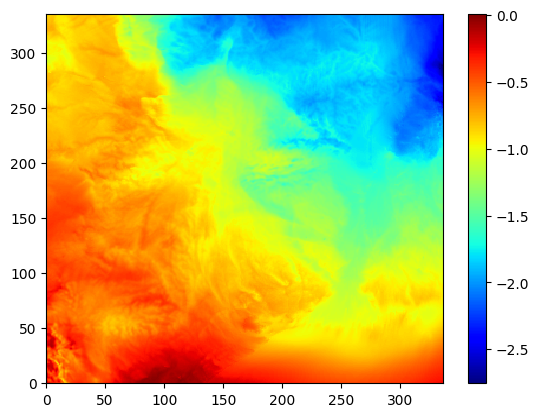

In [16]:
plt.pcolormesh(batch_single['x'][0, 2, 0, ...], cmap=plt.cm.jet)
plt.colorbar()

# Workspace

## dataset dev

In [19]:
_PERIOD_NS = int(np.timedelta64(6, "h") / np.timedelta64(1, "ns"))

def next_six_hour(dt):
    ns = dt.astype("int64")
    out = (ns // _PERIOD_NS + 1) * _PERIOD_NS
    return out.astype("datetime64[ns]")

def previous_six_hour_steps(time_pick, step):
    """
    Given a datetime64[ns] time_pick, compute time_pick - step * 6 hours.
    """
    return time_pick - np.timedelta64(6 * step, 'h')

In [20]:
# t0 = np.datetime64("2018-01-14T22:00:00")
# next_six_hour(t0)

In [21]:
def encode_datetime64(dt_array):
    dt_array = np.atleast_1d(dt_array).astype('datetime64[ns]')
    dt_s = dt_array.astype('datetime64[s]')

    # Time components
    seconds_in_day = 86400
    seconds_since_midnight = (dt_s - dt_s.astype('datetime64[D]')).astype('timedelta64[s]').astype(int)
    hour = seconds_since_midnight / 3600.0

    # Day of year
    year_start = dt_s.astype('datetime64[Y]')
    day_of_year = (dt_s - year_start).astype('timedelta64[D]').astype(int) + 1

    # Cyclical encodings
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    doy_sin = np.sin(2 * np.pi * day_of_year / 365.25)
    doy_cos = np.cos(2 * np.pi * day_of_year / 365.25)

    return np.concatenate((hour_sin, hour_cos, doy_sin, doy_cos), axis=0)

## boundary and interior data

In [5]:
ds_ERA5 = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/all_in_one/ERA5_GP_1980.zarr')

In [7]:
ds_ERA5

<xarray.Dataset>
Dimensions:    (time: 1464, latitude: 88, longitude: 112, level: 11)
Coordinates:
  * latitude   (latitude) float64 45.0 44.75 44.5 44.25 ... 23.75 23.5 23.25
  * level      (level) float64 50.0 100.0 200.0 300.0 ... 850.0 950.0 1e+03
  * longitude  (longitude) float64 250.2 250.5 250.8 251.0 ... 277.5 277.8 278.0
  * time       (time) datetime64[ns] 1980-01-01 ... 1980-12-31T18:00:00
Data variables:
    MSL        (time, latitude, longitude) float32 dask.array<chunksize=(4, 88, 112), meta=np.ndarray>
    Q          (time, level, latitude, longitude) float32 dask.array<chunksize=(4, 2, 88, 112), meta=np.ndarray>
    SP         (time, latitude, longitude) float32 dask.array<chunksize=(4, 88, 112), meta=np.ndarray>
    T          (time, level, latitude, longitude) float32 dask.array<chunksize=(4, 2, 88, 112), meta=np.ndarray>
    U          (time, level, latitude, longitude) float32 dask.array<chunksize=(4, 2, 88, 112), meta=np.ndarray>
    V          (time, level, latitude, longitude) float32 dask.array<chunksize=(4, 2, 88, 112), meta=np.ndarray>
    VAR_10U    (time, latitude, longitude) float32 dask.array<chunksize=(4, 88, 112), meta=np.ndarray>
    VAR_10V    (time, latitude, longitude) float32 dask.array<chunksize=(4, 88, 112), meta=np.ndarray>
    VAR_2T     (time, latitude, longitude) float32 dask.array<chunksize=(4, 88, 112), meta=np.ndarray>
    Z          (time, level, latitude, longitude) float32 dask.array<chunksize=(4, 2, 88, 112), meta=np.ndarray>
Attributes:
    CONVERSION_DATE:      Sun May 19 19:53:54 MDT 2019
    CONVERSION_PLATFORM:  Linux r1i0n9 3.12.62-60.64.8-default #1 SMP Tue Oct...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 4.7.4 (http://nco.sf.net)
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB 1 data to netC...
    NETCDF_VERSION:       4.6.1
    history:              Sun May 19 19:54:09 2019: ncks -4 --ppc default=7 e...

In [6]:
ds_C404 = xr.open_zarr('/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/all_in_one/C404_GP_1980.zarr')

In [8]:
ds_C404

<xarray.Dataset>
Dimensions:                    (time: 8784, south_north: 336, west_east: 336,
                                bottom_top: 12)
Coordinates:
  * time                       (time) datetime64[ns] 1980-01-01 ... 1980-12-3...
Dimensions without coordinates: south_north, west_east, bottom_top
Data variables: (12/14)
    WRF_MSLP                   (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_Q                      (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 12, 336, 336), meta=np.ndarray>
    WRF_SP                     (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_T                      (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 12, 336, 336), meta=np.ndarray>
    WRF_T2                     (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_TD2                    (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    ...                         ...
    WRF_V                      (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 12, 336, 336), meta=np.ndarray>
    WRF_V10                    (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_column_total_moisture  (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_evapor                 (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_precip                 (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_radar_composite        (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>

In [7]:
ds_static = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/static/C404_GP_static.zarr')

In [8]:
ds_static

<xarray.Dataset>
Dimensions:   (south_north: 336, west_east: 336)
Dimensions without coordinates: south_north, west_east
Data variables:
    HGT_M     (south_north, west_east) float32 dask.array<chunksize=(336, 336), meta=np.ndarray>
    LANDMASK  (south_north, west_east) float32 dask.array<chunksize=(336, 336), meta=np.ndarray>
    XLAT      (south_north, west_east) float32 dask.array<chunksize=(336, 336), meta=np.ndarray>
    XLONG     (south_north, west_east) float32 dask.array<chunksize=(336, 336), meta=np.ndarray>
    z_norm    (south_north, west_east) float32 dask.array<chunksize=(336, 336), meta=np.ndarray>
Attributes: (12/47)
    BOTTOM-TOP_GRID_DIMENSION:       0
    CEN_LAT:                         39.100006103515625
    CEN_LON:                         -97.89999389648438
    DX:                              4000.0
    DY:                              4000.0
    DYN_OPT:                         2
    ...                              ...
    j_parent_end:                    1016
    j_parent_start:                  1
    parent_grid_ratio:               1
    parent_id:                       1
    sr_x:                            1
    sr_y:                            1